In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [70]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [71]:
summary_files = glob.glob('results/**/**/summary.csv', recursive=True)
summary_files = list(set(summary_files))

In [72]:
cher_results = {}
for f in summary_files:
    parts = f.split('/')
    method = parts[1]
    dataset = parts[2]
    df = pd.read_csv(f)
    df = df[df['classification'] != 'total']
    cher_results[f"cher_{method}_{dataset}"] = df

In [73]:
#to list all datasets and methods
"""for key, df in cher_results.items():
    print(key)"""

'for key, df in cher_results.items():\n    print(key)'

In [74]:
#to display dfs
"""for key, df in cher_results.items():
    print(key)
    display(df)"""

'for key, df in cher_results.items():\n    print(key)\n    display(df)'

In [75]:
cher_results['cher_demultiplex_mcginnis_ms']

,classification,n,dataset,method
0,doublet,280,mcginnis_ms,demultiplex
1,negative,323,mcginnis_ms,demultiplex
2,singlet,4556,mcginnis_ms,demultiplex


#### Helper Functions

In [76]:
def create_summary_xcol(calls, method, dataset):
    df = pd.read_csv(calls) 
    df = df.rename(columns={'x': 'classification'})
    df = df.drop(columns=('Unnamed: 0'))

    df['classification'] = df['classification'].replace({
        0: 'negative',
        1000: 'doublet'
    })

    df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

    summary = df['classification'].value_counts().reset_index()
    summary.columns = ['classification', 'n']
    summary = summary.sort_values(by='n', ascending=True)
    summary['dataset'] = dataset
    summary['method'] = method
    
    return summary

In [77]:
def create_summary(calls, method, dataset):
    df = pd.read_csv(calls) 
    df = df.rename(columns={'Classification': 'classification'})
    df = df.drop(columns=('Unnamed: 0'))

    df['classification'] = df['classification'].replace({
        0: 'negative',
        1000: 'doublet'
    })

    df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

    summary = df['classification'].value_counts().reset_index()
    summary.columns = ['classification', 'n']
    summary = summary.sort_values(by='n', ascending=True)
    summary['dataset'] = dataset
    summary['method'] = method
    
    return summary

### McGinnis Datasets

In [78]:
#mciginnis_ms
brian_demultiplex_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demultiplex.csv', 'demultiplex', 'mcginnis_ms')
brian_demultiplex2_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demultiplex2.csv', 'demultiplex2', 'mcginnis_ms')
brian_htodemux_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_htodemux.csv', 'htodemux', 'mcginnis_ms')
brian_hashsolo_mcginnis_ms = create_summary('brian-scripts/McGinnis_calls/labels_mcginnis_ms_hsolo.csv', 'hashsolo', 'mcginnis_ms')
brian_bffcluster_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_bff_cluster.csv', 'bff_cluster', 'mcginnis_ms')
brian_bffraw_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_bff_raw.csv', 'bff_raw', 'mcginnis_ms')
brian_hasheddrops_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_hashed.csv', 'hasheddrops', 'mcginnis_ms')
brian_demuxmix_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demuxmix.csv', 'demuxmix', 'mcginnis_ms')
brian_demuxmixnaive_mcginnis_ms	 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demuxmix_naive.csv', 'demuxmix naive', 'mcginnis_ms')




In [79]:
df = pd.read_csv('brian-scripts/McGinnis_calls/labels_mcginnis_ms_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'mcginnis_ms'
summary['method'] = 'gmmdemux'

brian_gmmdemux_mcginnis_ms = summary
brian_gmmdemux_mcginnis_ms


,classification,n,dataset,method
2,doublet,264,mcginnis_ms,gmmdemux
1,negative,387,mcginnis_ms,gmmdemux
0,singlet,4508,mcginnis_ms,gmmdemux


In [80]:
#mcginnis_hto
brian_demultiplex_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demultiplex.csv', 'demultiplex', 'mcginnis_hto')
brian_demultiplex2_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demultiplex2.csv', 'demultiplex2', 'mcginnis_hto')
brian_htodemux_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_htodemux.csv', 'htodemux', 'mcginnis_hto')
brian_hashsolo_mcginnis_hto = create_summary('brian-scripts/McGinnis_calls/labels_mcginnis_hto_hsolo.csv', 'hashsolo', 'mcginnis_hto')
brian_bffcluster_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_bff_cluster.csv', 'bff_cluster', 'mcginnis_hto')
brian_bffraw_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_bff_raw.csv', 'bff_raw', 'mcginnis_hto')
brian_hasheddrops_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_hashed.csv', 'hasheddrops', 'mcginnis_hto')
brian_demuxmix_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demuxmix.csv', 'demuxmix', 'mcginnis_hto')
brian_demuxmixnaive_mcginnis_hto = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demuxmix_naive.csv', 'demuxmix naive', 'mcginnis_hto')

In [81]:
df = pd.read_csv('brian-scripts/McGinnis_calls/labels_mcginnis_hto_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'mcginnis_hto'
summary['method'] = 'gmmdemux'

brian_gmmdemux_mcginnis_hto = summary
brian_gmmdemux_mcginnis_hto


,classification,n,dataset,method
1,negative,1787,mcginnis_hto,gmmdemux
0,doublet,3372,mcginnis_hto,gmmdemux


### Winkler Datasets

In [82]:
#winkler_pdx1a
brian_bffcluster_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_bff_cluster.csv', 'bff_cluster', 'winkler_pdx1a')
brian_bffraw_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_bff_raw.csv', 'bff_raw', 'winkler_pdx1a')
brian_demultiplex_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_demultiplex.csv', 'demultiplex', 'winkler_pdx1a')
brian_demultiplex2_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_demultiplex2.csv', 'demultiplex2', 'winkler_pdx1a')
brian_hasheddrops_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_hasheddrops.csv', 'hasheddrops', 'winkler_pdx1a')
brian_hashsolo_winkler_pdx1a = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx1a_hashsolo.csv', 'hashsolo', 'winkler_pdx1a')
brian_htodemux_winkler_pdx1a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1a_htodemux.csv', 'htodemux', 'winkler_pdx1a')

In [83]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx1a_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx1a'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx1a = summary
brian_gmmdemux_winkler_pdx1a

,classification,n,dataset,method
2,singlet,10,winkler_pdx1a,gmmdemux
1,negative,333,winkler_pdx1a,gmmdemux
0,doublet,1441,winkler_pdx1a,gmmdemux


In [84]:
#winkler_pdx1b
brian_bffcluster_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_bff_cluster.csv', 'bff_cluster', 'winkler_pdx1b')
brian_bffraw_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_bff_raw.csv', 'bff_raw', 'winkler_pdx1b')
brian_demultiplex_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_demultiplex.csv', 'demultiplex', 'winkler_pdx1b')
brian_demultiplex2_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_demultiplex2.csv', 'demultiplex2', 'winkler_pdx1b')
brian_hasheddrops_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_hasheddrops.csv', 'hasheddrops', 'winkler_pdx1b')
brian_hashsolo_winkler_pdx1b = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx1b_hashsolo.csv', 'hashsolo', 'winkler_pdx1b')
brian_htodemux_winkler_pdx1b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1b_htodemux.csv', 'htodemux', 'winkler_pdx1b')

In [85]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx1b_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx1b'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx1b = summary
brian_gmmdemux_winkler_pdx1b

,classification,n,dataset,method
2,singlet,23,winkler_pdx1b,gmmdemux
1,negative,332,winkler_pdx1b,gmmdemux
0,doublet,1581,winkler_pdx1b,gmmdemux


In [86]:
#winkler_pdx1c
brian_bffcluster_winkler_pdx1c = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1c_bff_cluster.csv', 'bff_cluster', 'winkler_pdx1c')
brian_bffraw_winkler_pdx1c = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1c_bff_raw.csv', 'bff_raw', 'winkler_pdx1c')
brian_demultiplex_winkler_pdx1c = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1c_demultiplex.csv', 'demultiplex', 'winkler_pdx1c')
brian_demultiplex2_winkler_pdx1c = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1c_demultiplex2.csv', 'demultiplex2', 'winkler_pdx1c')
brian_hasheddrops_winkler_pdx1c = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1c_hasheddrops.csv', 'hasheddrops', 'winkler_pdx1c')
brian_hashsolo_winkler_pdx1c = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx1c_hashsolo.csv', 'hashsolo', 'winkler_pdx1c')

In [87]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx1c_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx1c'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx1c = summary
brian_gmmdemux_winkler_pdx1c

,classification,n,dataset,method
2,singlet,90,winkler_pdx1c,gmmdemux
1,negative,534,winkler_pdx1c,gmmdemux
0,doublet,1388,winkler_pdx1c,gmmdemux


In [88]:
#winkler_pdx1d
brian_bffcluster_winkler_pdx1d = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1d_bff_cluster.csv', 'bff_cluster', 'winkler_pdx1d')
brian_bffraw_winkler_pdx1d = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1d_bff_raw.csv', 'bff_raw', 'winkler_pdx1d')
brian_demultiplex_winkler_pdx1d = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1d_demultiplex.csv', 'demultiplex', 'winkler_pdx1d')
brian_demultiplex2_winkler_pdx1d = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1d_demultiplex2.csv', 'demultiplex2', 'winkler_pdx1d')
brian_hasheddrops_winkler_pdx1d = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx1d_hasheddrops.csv', 'hasheddrops', 'winkler_pdx1d')
brian_hashsolo_winkler_pdx1d = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx1d_hashsolo.csv', 'hashsolo', 'winkler_pdx1d')

In [89]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx1d_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx1d'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx1d = summary
brian_gmmdemux_winkler_pdx1d

,classification,n,dataset,method
2,singlet,15,winkler_pdx1d,gmmdemux
1,negative,794,winkler_pdx1d,gmmdemux
0,doublet,1108,winkler_pdx1d,gmmdemux


In [90]:
#winkler_pdx3a
brian_bffcluster_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_bff_cluster.csv', 'bff_cluster', 'winkler_pdx3a')
brian_bffraw_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_bff_raw.csv', 'bff_raw', 'winkler_pdx3a')
brian_demultiplex_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_demultiplex.csv', 'demultiplex', 'winkler_pdx3a')
brian_demultiplex2_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_demultiplex2.csv', 'demultiplex2', 'winkler_pdx3a')
brian_hasheddrops_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_hasheddrops.csv', 'hasheddrops', 'winkler_pdx3a')
brian_hashsolo_winkler_pdx3a = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx3a_hashsolo.csv', 'hashsolo', 'winkler_pdx3a')
brian_htodemux_winkler_pdx3a = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3a_htodemux.csv', 'htodemux', 'winkler_pdx3a')

In [91]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx3a_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx3a'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx3a = summary
brian_gmmdemux_winkler_pdx3a

,classification,n,dataset,method
0,negative,3532,winkler_pdx3a,gmmdemux


In [92]:
#winkler_pdx3b
brian_bffcluster_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_bff_cluster.csv', 'bff_cluster', 'winkler_pdx3b')
brian_bffraw_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_bff_raw.csv', 'bff_raw', 'winkler_pdx3b')
brian_demultiplex_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_demultiplex.csv', 'demultiplex', 'winkler_pdx3b')
brian_demultiplex2_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_demultiplex2.csv', 'demultiplex2', 'winkler_pdx3b')
brian_hasheddrops_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_hasheddrops.csv', 'hasheddrops', 'winkler_pdx3b')
brian_hashsolo_winkler_pdx3b = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx3b_hashsolo.csv', 'hashsolo', 'winkler_pdx3b')
brian_htodemux_winkler_pdx3b = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_htodemux.csv', 'htodemux', 'winkler_pdx3b')

In [93]:
df = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx3b_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'doublet'
})

df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'winkler_pdx3b'
summary['method'] = 'gmmdemux'

brian_gmmdemux_winkler_pdx3b = summary
brian_gmmdemux_winkler_pdx3b

,classification,n,dataset,method
0,negative,3532,winkler_pdx3b,gmmdemux


### Gaublomme Dataset

### Graph Comparisons

In [94]:
brian_results = pd.concat([
   brian_demultiplex_mcginnis_ms,
   brian_demultiplex2_mcginnis_ms,
   brian_htodemux_mcginnis_ms,
   brian_hashsolo_mcginnis_ms,
   brian_bffcluster_mcginnis_ms,
   brian_bffraw_mcginnis_ms,
   brian_gmmdemux_mcginnis_ms,
   brian_hasheddrops_mcginnis_ms,
   brian_demuxmix_mcginnis_ms,
   brian_demuxmixnaive_mcginnis_ms,

   brian_demultiplex_mcginnis_hto, 
   brian_demultiplex2_mcginnis_hto,
   brian_htodemux_mcginnis_hto,
   brian_hashsolo_mcginnis_hto,
   brian_bffcluster_mcginnis_hto,
   brian_bffraw_mcginnis_hto,
   brian_gmmdemux_mcginnis_hto,
   brian_hasheddrops_mcginnis_hto,
   brian_demuxmix_mcginnis_hto,
   brian_demuxmixnaive_mcginnis_hto,

   brian_demultiplex_winkler_pdx1a,
   brian_demultiplex2_winkler_pdx1a,
   brian_htodemux_winkler_pdx1a,
   brian_hashsolo_winkler_pdx1a,
   brian_bffcluster_winkler_pdx1a,
   brian_bffraw_winkler_pdx1a,
   brian_gmmdemux_winkler_pdx1a,
   brian_hasheddrops_winkler_pdx1a,
   
   brian_demultiplex_winkler_pdx1b,
   brian_demultiplex2_winkler_pdx1b,
   brian_htodemux_winkler_pdx1b,
   brian_hashsolo_winkler_pdx1b,
   brian_bffcluster_winkler_pdx1b,
   brian_bffraw_winkler_pdx1b,
   brian_gmmdemux_winkler_pdx1b,
   brian_hasheddrops_winkler_pdx1b,

   brian_demultiplex_winkler_pdx1c,
   brian_demultiplex2_winkler_pdx1c,
   brian_hashsolo_winkler_pdx1c,
   brian_bffcluster_winkler_pdx1c,
   brian_bffraw_winkler_pdx1c,
   brian_gmmdemux_winkler_pdx1c,
   brian_hasheddrops_winkler_pdx1c,

   brian_demultiplex_winkler_pdx1d,
   brian_demultiplex2_winkler_pdx1d,
   brian_hashsolo_winkler_pdx1d,
   brian_bffcluster_winkler_pdx1d,
   brian_bffraw_winkler_pdx1d,
   brian_gmmdemux_winkler_pdx1d,
   brian_hasheddrops_winkler_pdx1d,

   brian_demultiplex_winkler_pdx3a,
   brian_demultiplex2_winkler_pdx3a,
   brian_htodemux_winkler_pdx3a,
   brian_hashsolo_winkler_pdx3a,
   brian_bffcluster_winkler_pdx3a,
   brian_bffraw_winkler_pdx3a,
   brian_gmmdemux_winkler_pdx3a,
   brian_hasheddrops_winkler_pdx3a,

   brian_demultiplex_winkler_pdx3b,
   brian_demultiplex2_winkler_pdx3b,
   brian_htodemux_winkler_pdx3b,
   brian_hashsolo_winkler_pdx3b,
   brian_bffcluster_winkler_pdx3b,
   brian_bffraw_winkler_pdx3b,
   brian_gmmdemux_winkler_pdx3b,
   brian_hasheddrops_winkler_pdx3b,
   ], ignore_index=True)

In [95]:
#read and combine
cher_results = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

#save combined dataframe
cher_results.to_csv('results/all_results.csv', index=False)

cher_results

,classification,n,dataset,method
0,doublet,132,winkler_pdx1c,bff_cluster
1,negative,3,winkler_pdx1c,bff_cluster
2,singlet,1877,winkler_pdx1c,bff_cluster
3,total,2012,winkler_pdx1c,bff_cluster
4,doublet,4916,mcginnis_hto,bff_raw
...,...,...,...,...
235,total,3532,winkler_pdx3a,hashsolo
236,doublet,664,mcginnis_hto,demuxmix
237,negative,1421,mcginnis_hto,demuxmix
238,singlet,2565,mcginnis_hto,demuxmix


In [96]:
plot_data = cher_results[cher_results['classification'] != 'total'].copy()

datasets = plot_data['dataset'].unique()

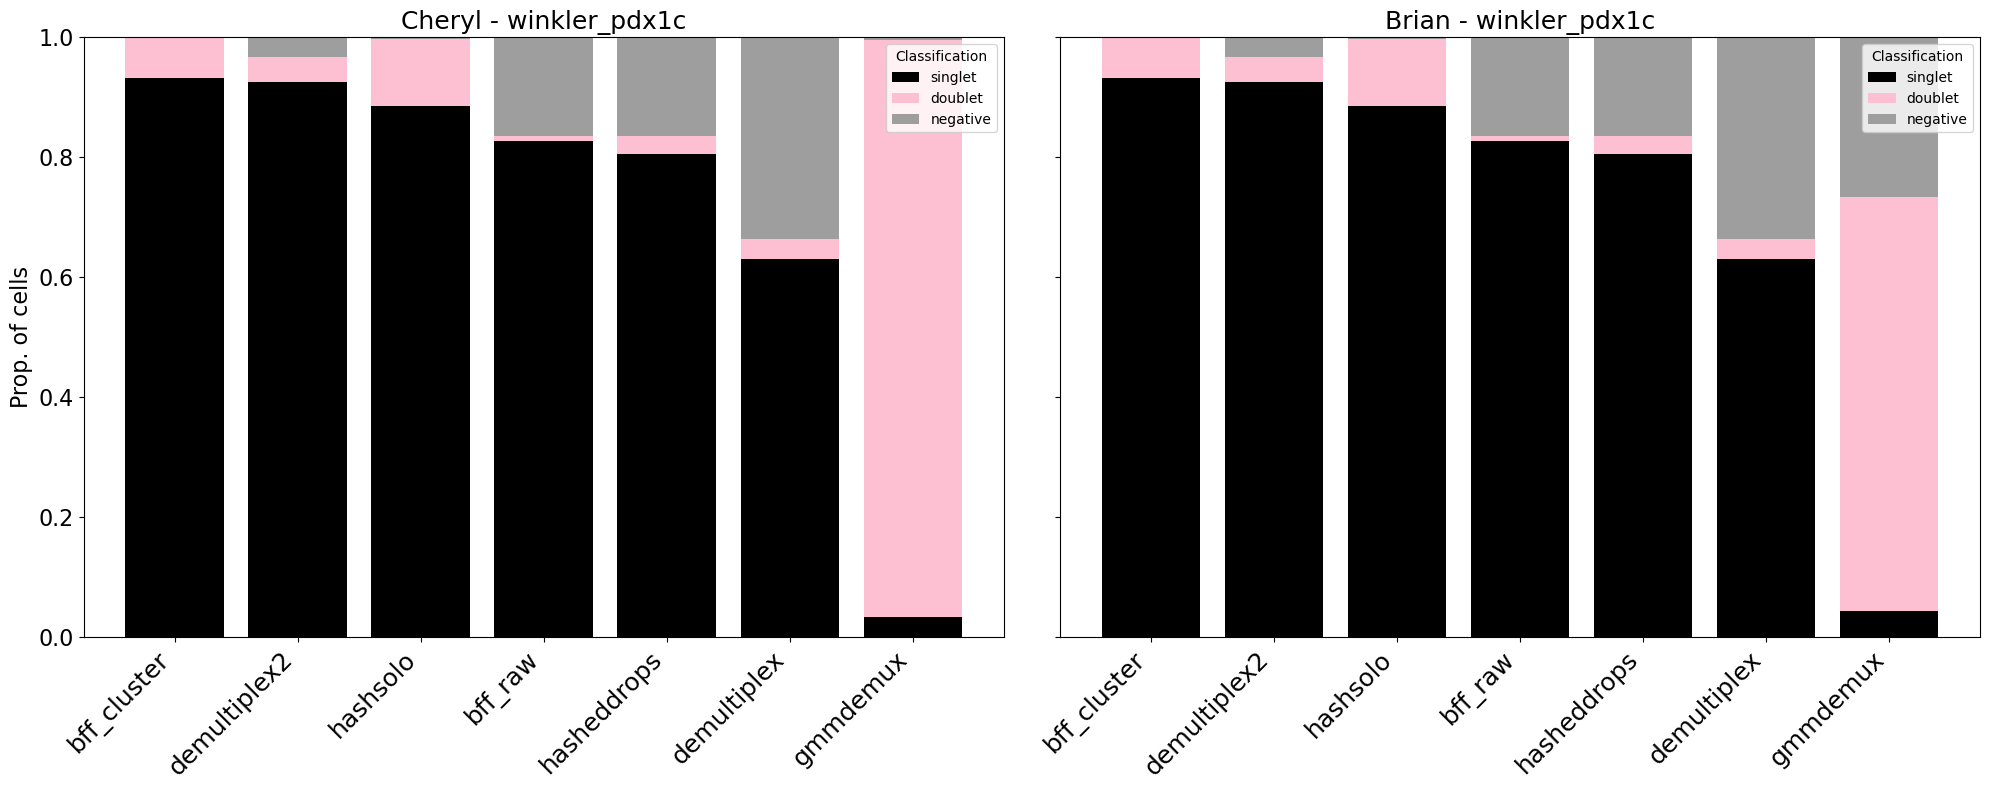

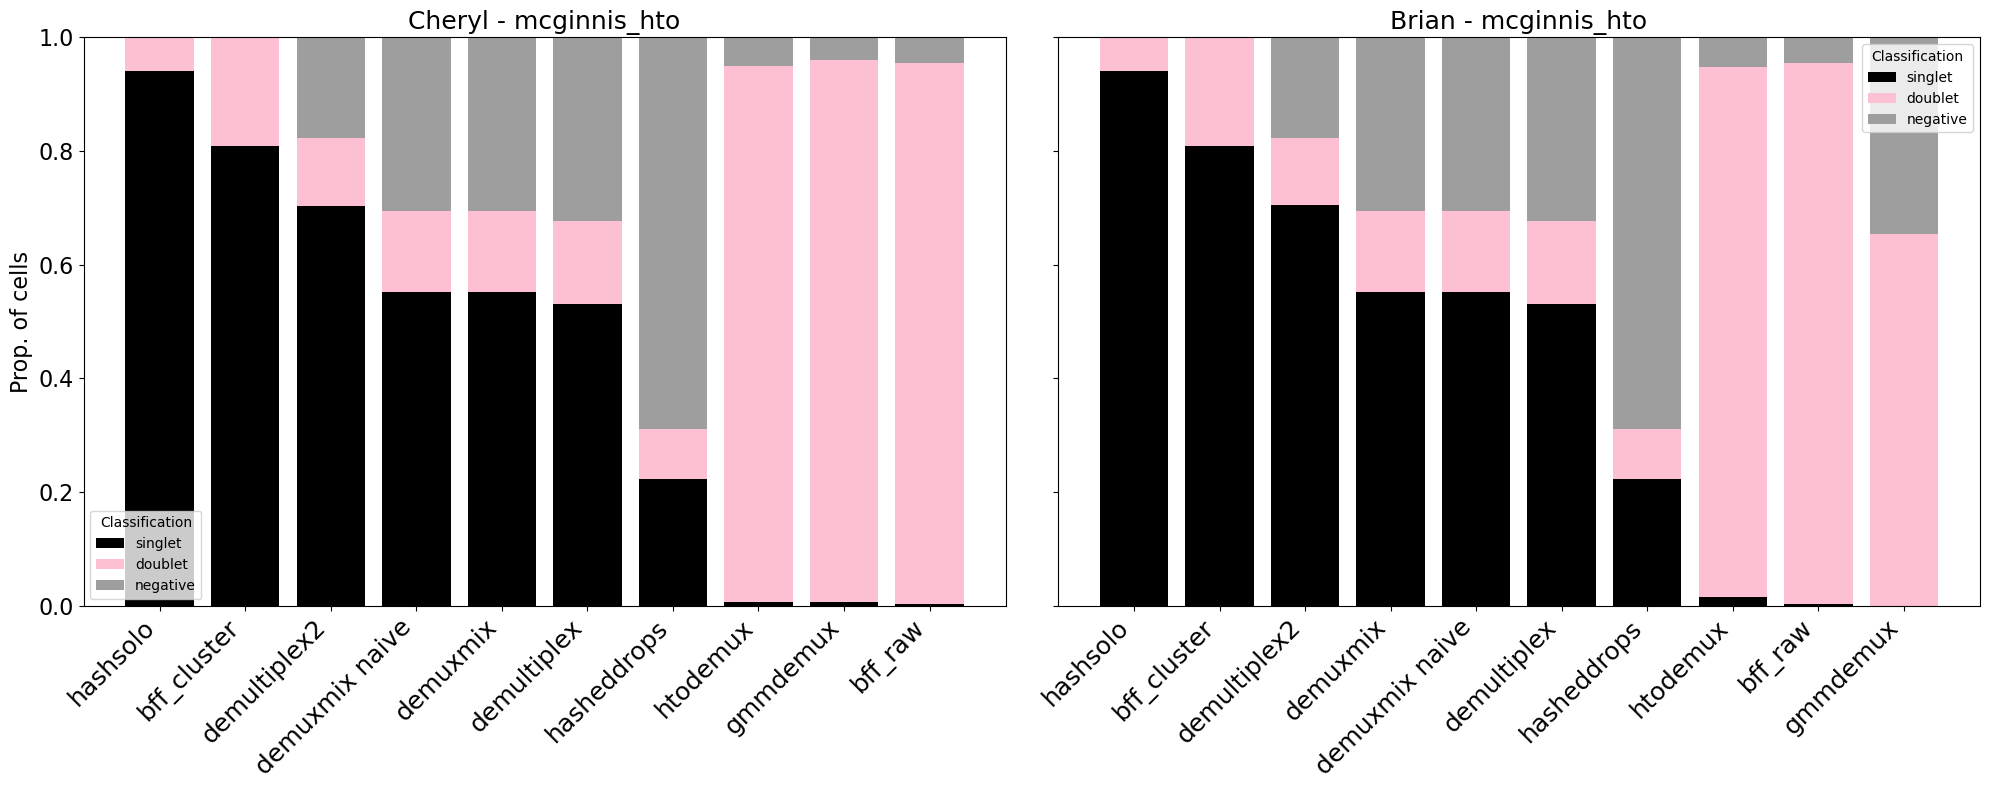

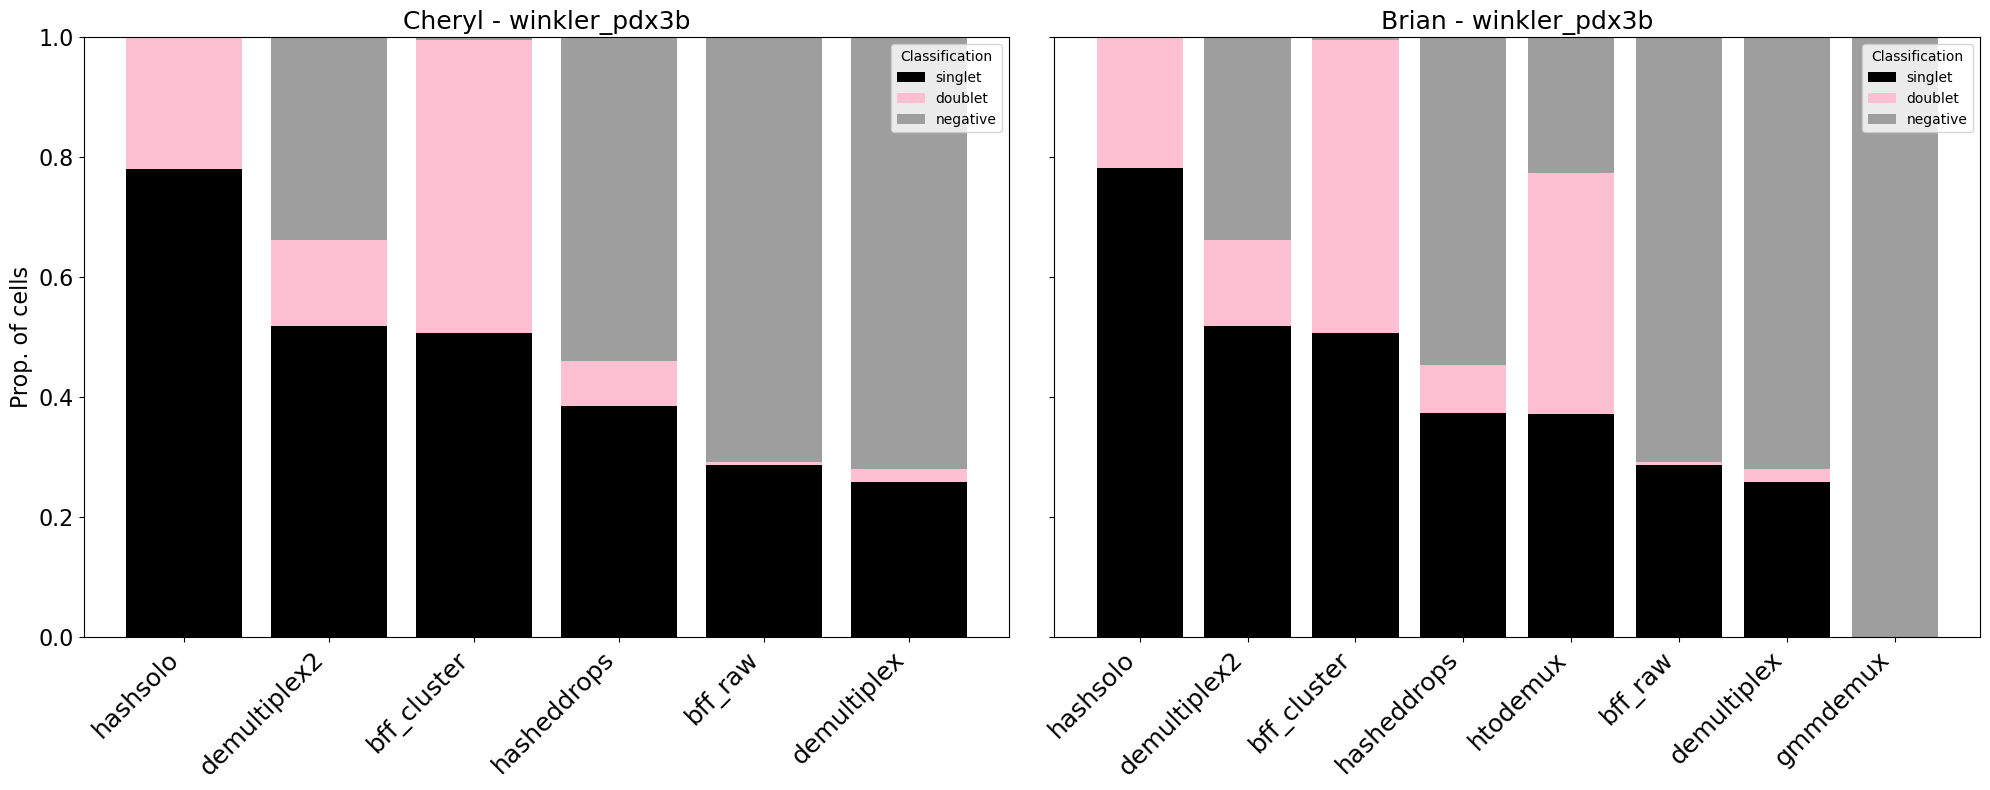

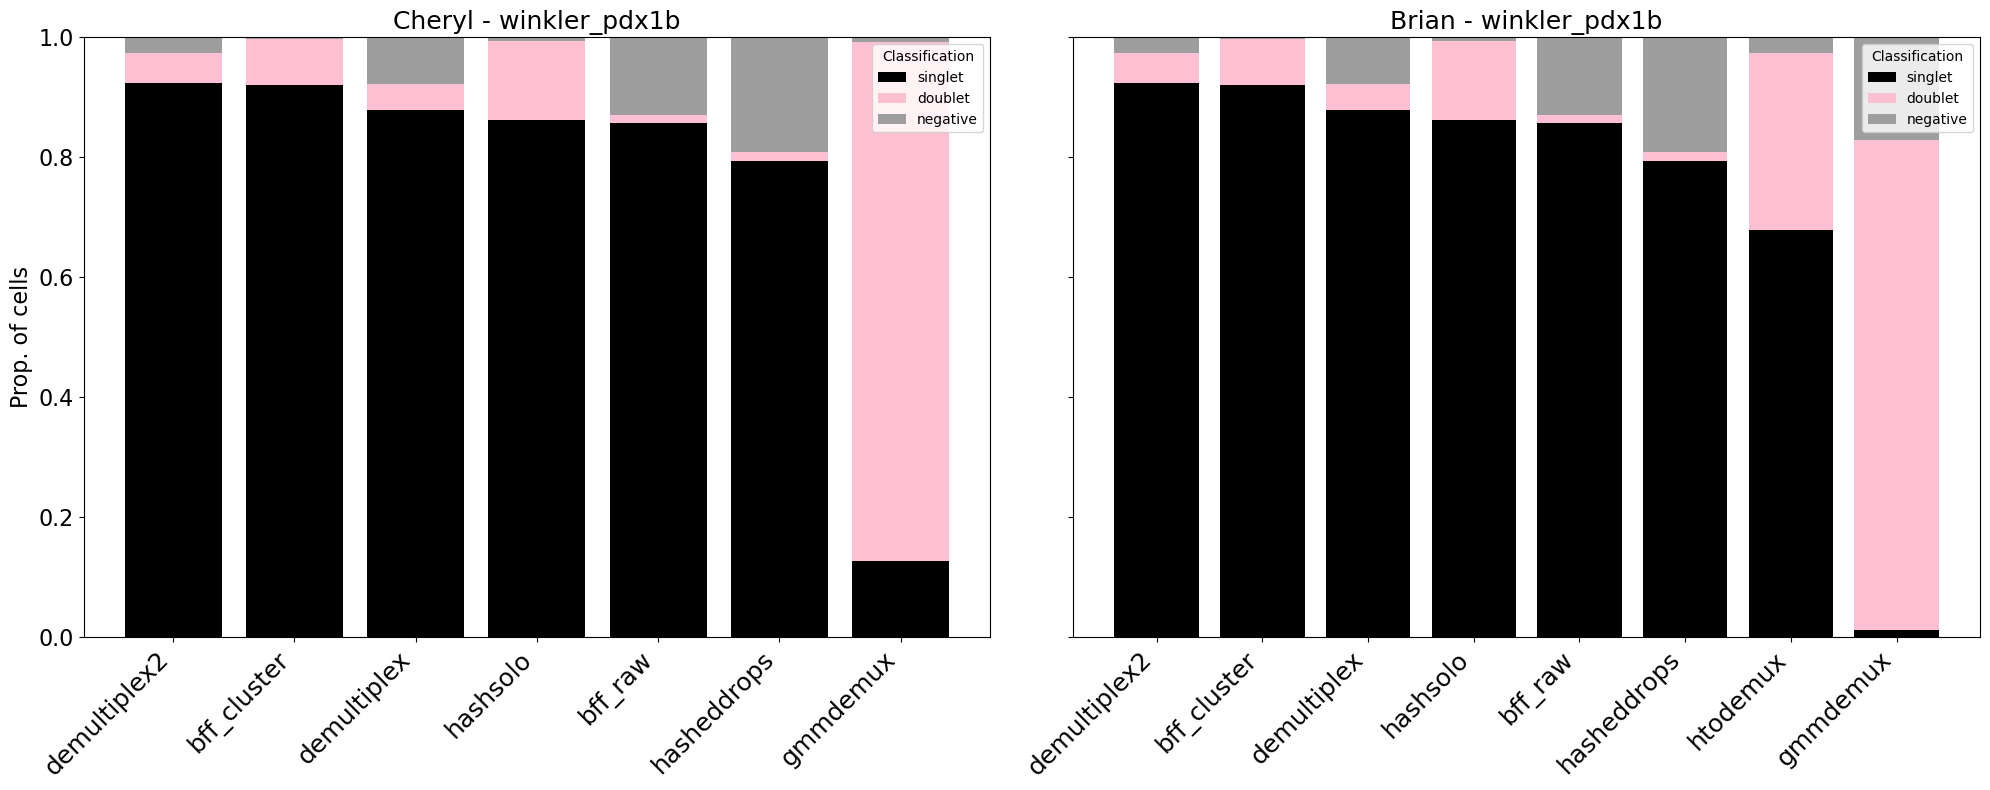

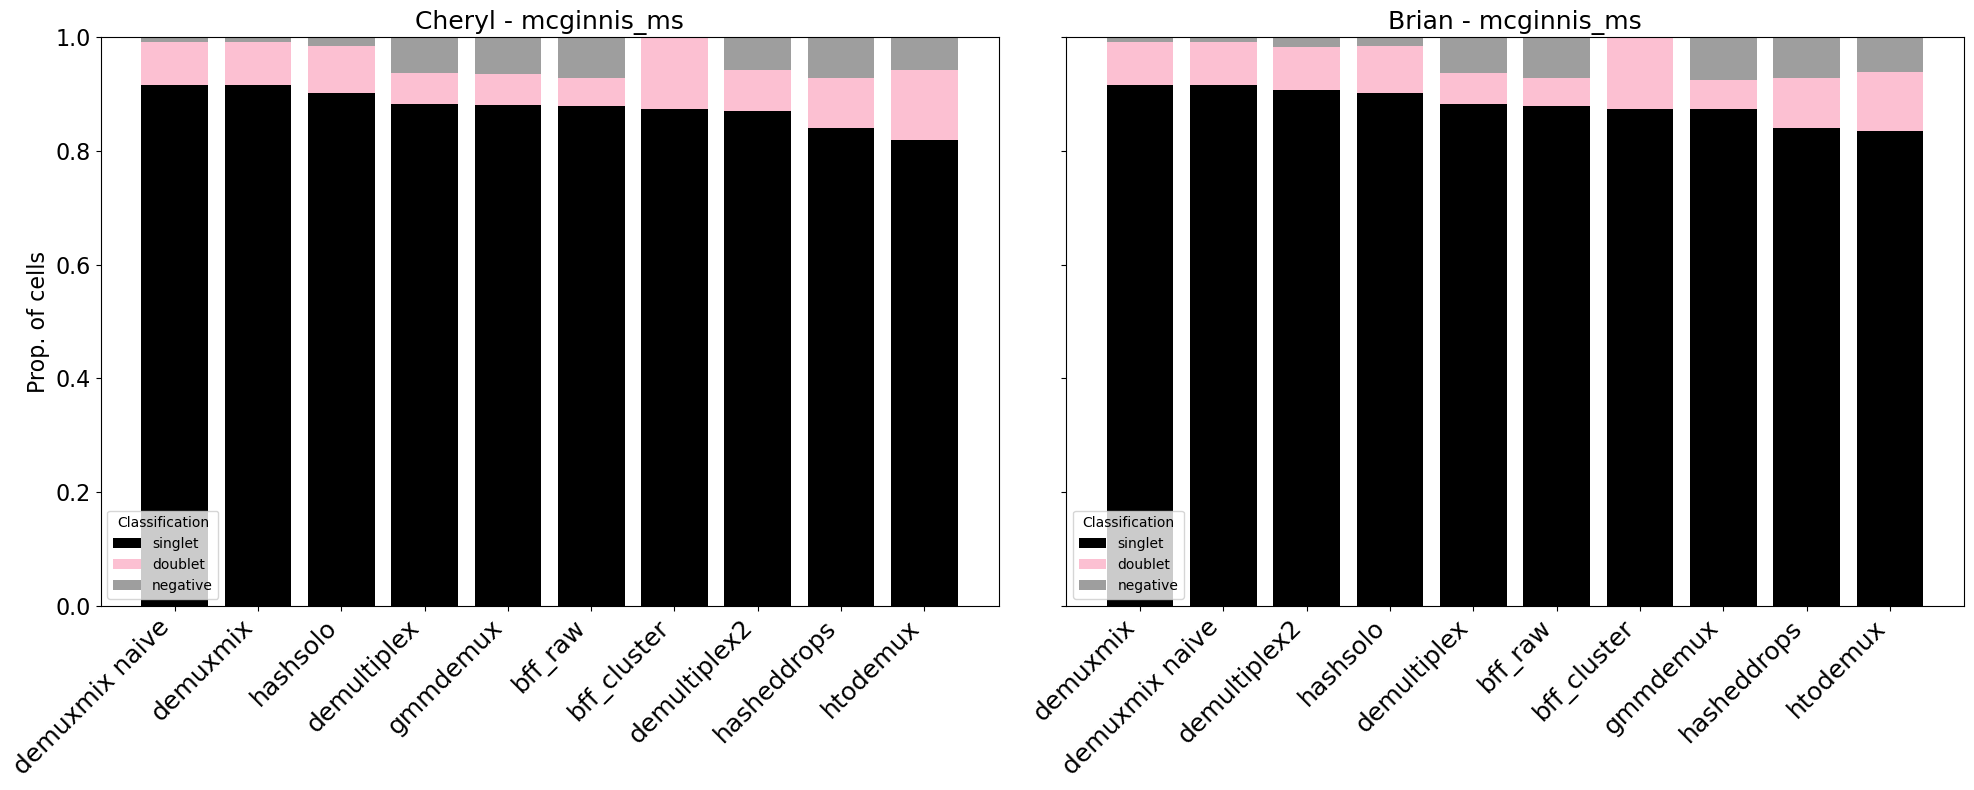

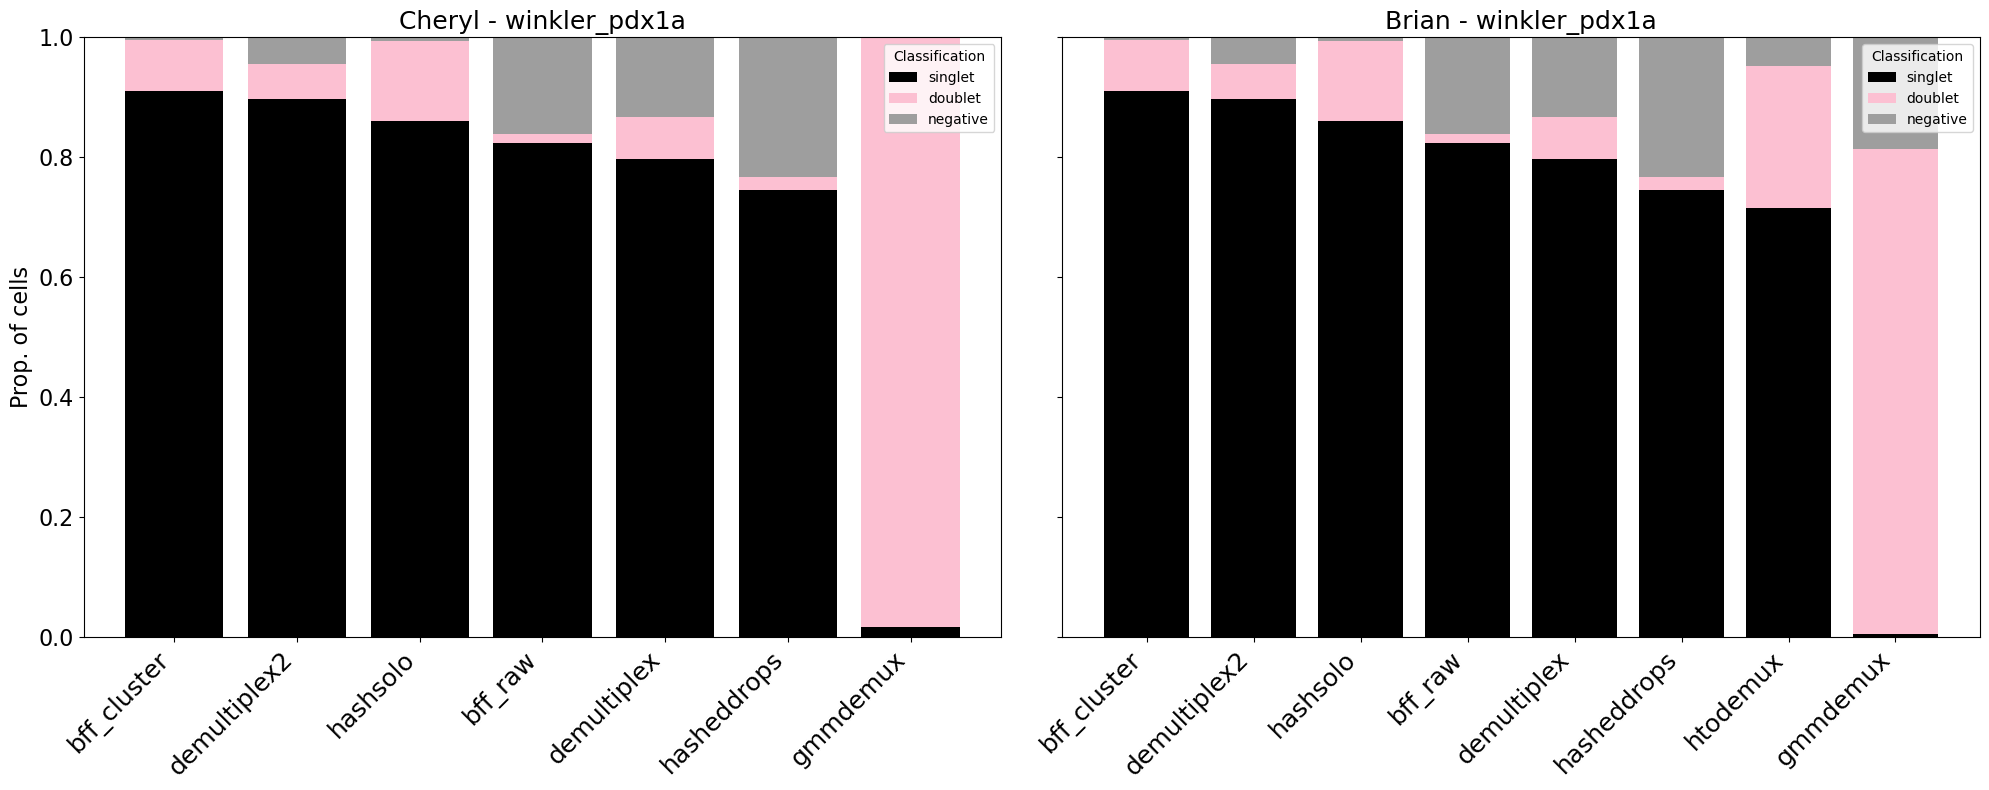

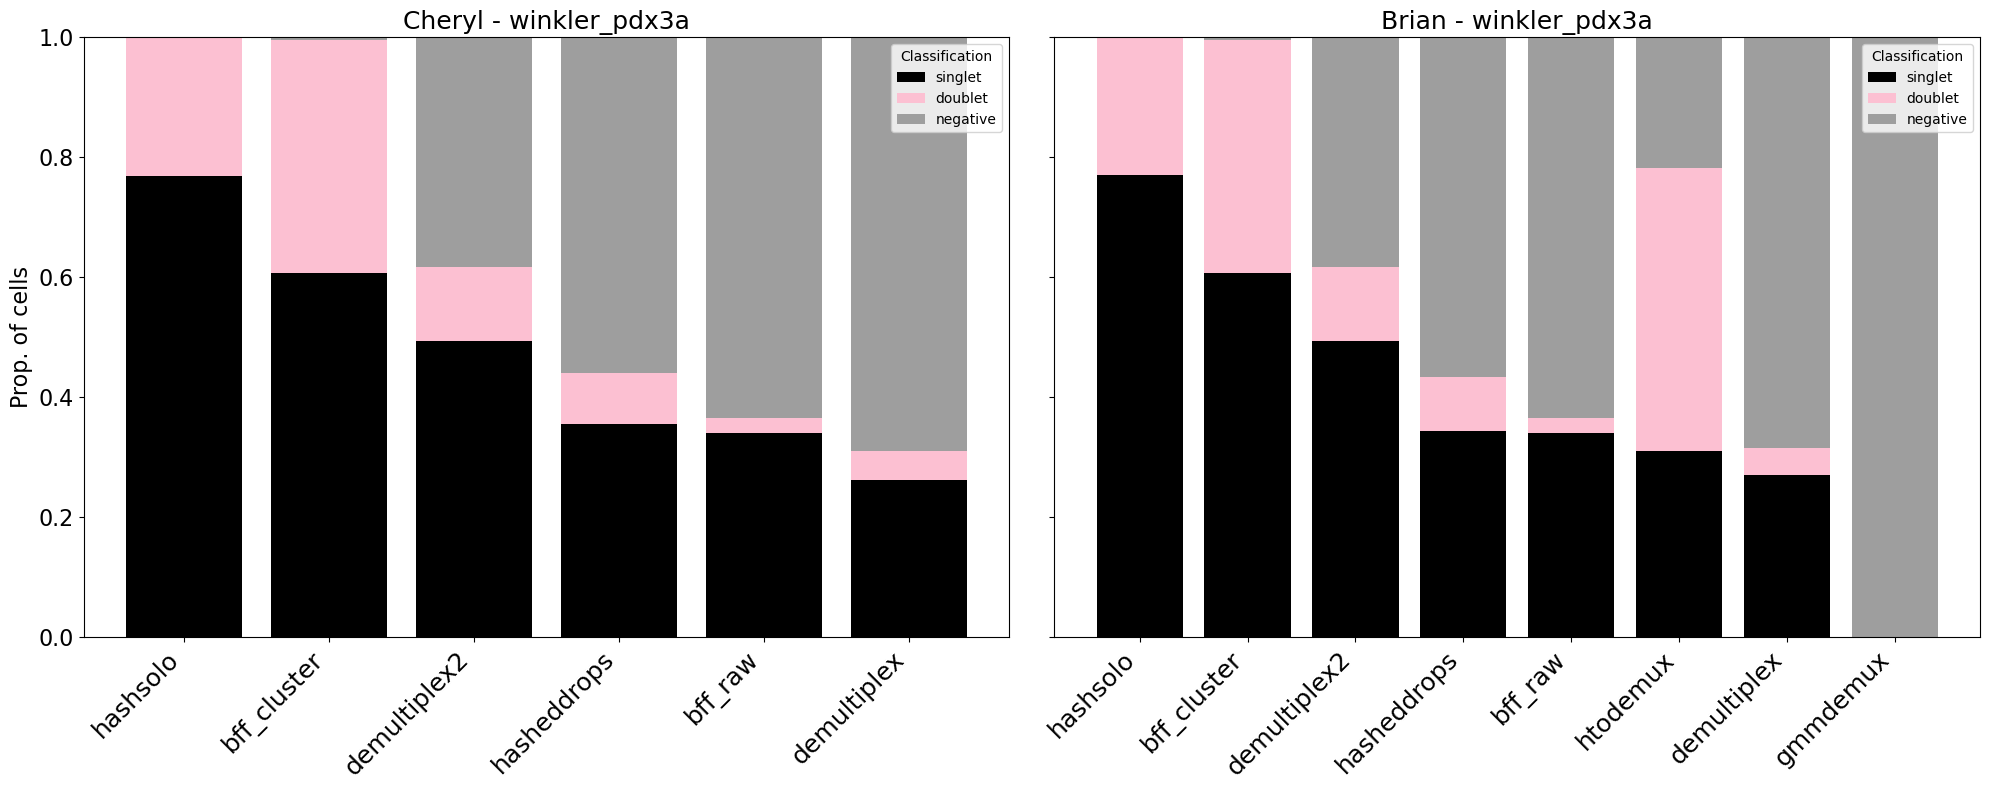

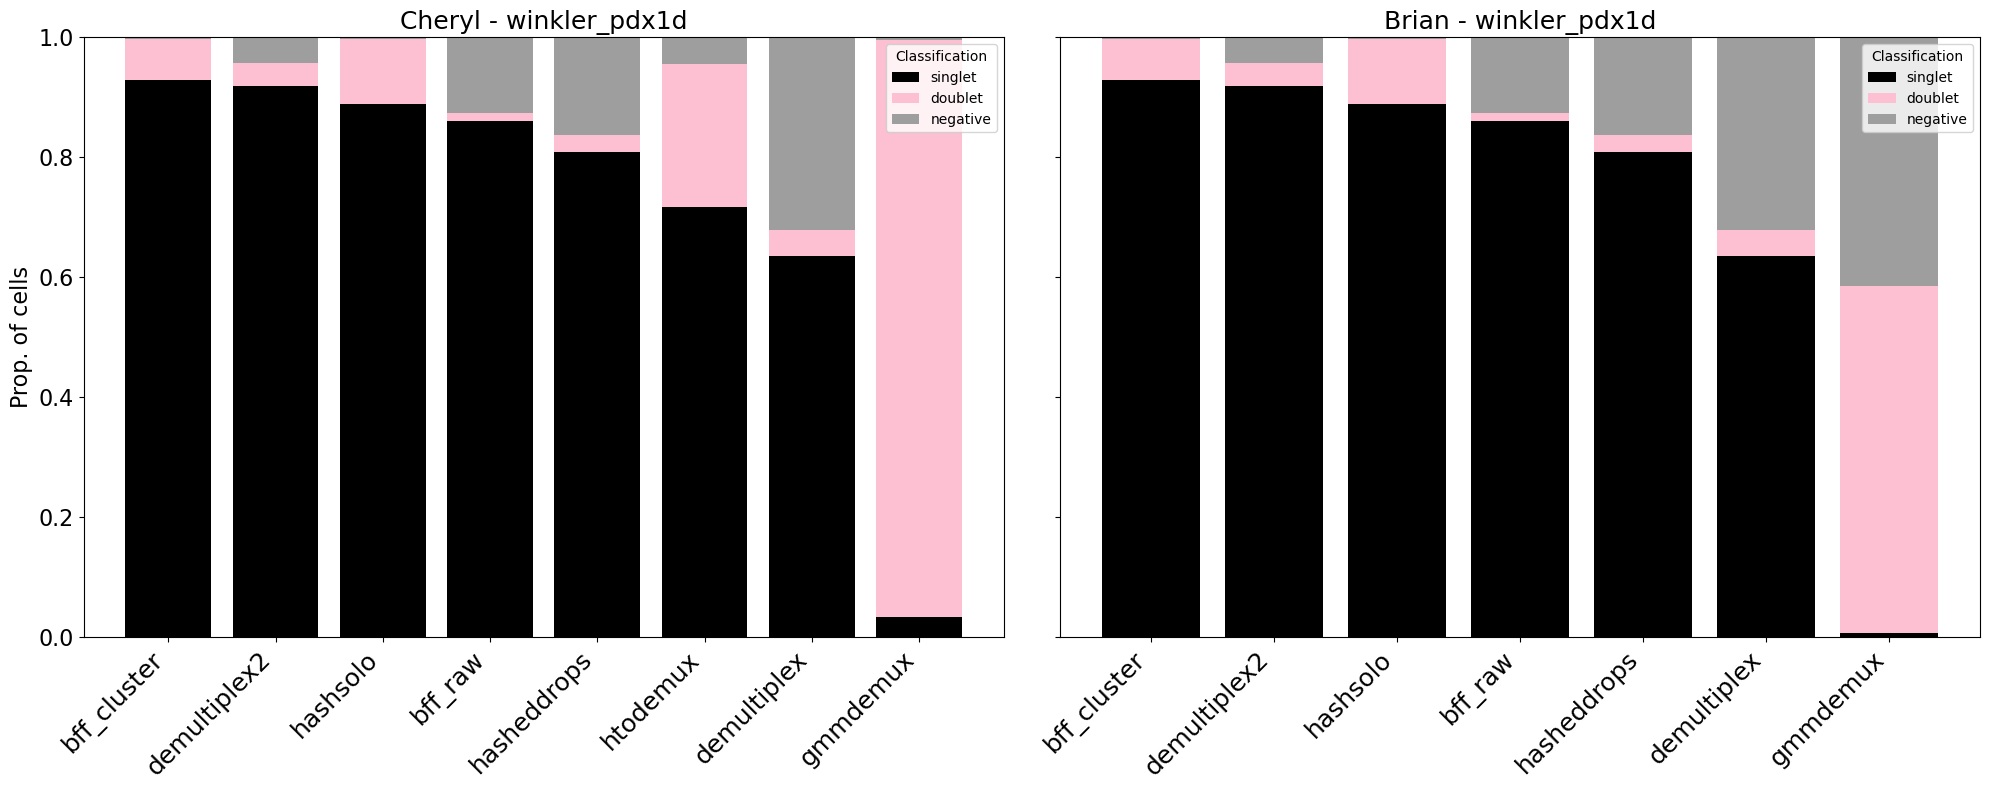

In [97]:
colors = {
    'singlet':  '#000000', 
    'doublet':  '#fcc0d2', 
    'negative': '#9E9E9E'
}

for dataset in datasets:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    
    for ax, (data, title) in zip([ax1, ax2], [
        (plot_data[plot_data['dataset'] == dataset], 'Cheryl'),
        (brian_results[brian_results['dataset'] == dataset], 'Brian')
    ]):
        df = data.copy()
        df['proportion'] = df.groupby('method')['n'].transform(lambda x: x / x.sum())

        pivot = df.pivot_table(
            index='method',
            columns='classification',
            values='proportion',
            fill_value=0
        )

        col_order = [c for c in ['singlet', 'doublet', 'negative'] if c in pivot.columns]
        pivot = pivot[col_order]

        # sort by singlet then multiplet
        sort_order = df[df['classification'] == 'singlet'][['method', 'proportion']].rename(columns={'proportion': 'singlet_prop'})
        # add methods with no singlets with 0 singlet proportion
        all_methods = df['method'].unique()
        missing = pd.DataFrame({
            'method': [m for m in all_methods if m not in sort_order['method'].values],
            'singlet_prop': 0
        })
        sort_order = pd.concat([sort_order, missing], ignore_index=True)

        sort_order = sort_order.sort_values(['singlet_prop'], ascending=[False])
        pivot = pivot.loc[sort_order['method'].tolist()] 

        bottom = pd.Series([0] * len(pivot), index=pivot.index)
        for classification in col_order:
            ax.bar(pivot.index, pivot[classification],
                   bottom=bottom,
                   label=classification,
                   color=colors[classification])
            bottom += pivot[classification]

        ax.set_title(f'{title} - {dataset}', fontsize=18)
        #ax.set_xlabel('Method')
        ax.set_ylim(0, 1)
        ax.legend(title='Classification')
        ax.tick_params(axis='y', labelsize=16)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=18)

    ax1.set_ylabel('Prop. of cells', fontsize=16)
    #plt.suptitle(f'Demultiplexing classifications - {dataset}', fontsize=14)
    plt.tight_layout()

    os.makedirs(f'results/figures/{dataset}', exist_ok=True)
    plt.savefig(f'results/figures/{dataset}/comparison_stacked_bar.pdf')
    plt.show()